# Factor Bar Chart and Timeseries Figures

In [649]:
import numpy as np
import seaborn as sns
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter

In [650]:
# force the math text to look normal
mpl.rcParams['mathtext.default'] = 'regular'

def major_ticks(x, pos=None):
    """Set the major ticks according 
    to this custom style
    """
    x = mdates.num2date(x)
    if pos == 0:
        fmt = "%-d\n%b %Y\n%I %p"
    else:
        fmt = "%-d"
    return x.strftime(fmt)

# set the default seaborn params
sns.set("paper", "ticks", color_codes=True, palette='colorblind')

## Loading Data

In [651]:
#load in the comp data
comp = pd.read_csv('/home/pmg2147/ModulAir NMF/OceanRoof/4_factor_resid.csv')
comp.rename(columns={'Unnamed: 0':'species'},inplace=True)
comp

,species,Factor 1,Factor 2,Factor 3,Factor 4,Residual
0,co,0.463150,0.171086,0.366547,0.000000,-0.000783
1,no,0.189588,0.422762,0.284371,0.044776,0.058502
2,no2,0.968659,0.000000,0.000000,0.031331,0.000011
3,o3,0.123114,0.870887,0.000000,0.006604,-0.000605
4,bin0,0.155901,0.000000,0.715696,0.127830,0.000573
5,bin1,0.000000,0.000000,0.729353,0.455936,-0.185289
6,bin2,0.000000,0.000000,0.413801,0.643696,-0.057497
7,bin3,0.041866,0.077903,0.117758,0.769296,-0.006822
8,bin4,0.002856,0.194279,0.000000,0.803056,-0.000191
9,bin5,0.000000,0.043491,0.000000,0.958044,-0.001536


In [652]:
comp2 = pd.melt(comp,id_vars='species', value_vars=['Factor 1','Factor 2','Factor 3','Factor 4','Residual'])
comp2

,species,variable,value
0,co,Factor 1,0.463150
1,no,Factor 1,0.189588
2,no2,Factor 1,0.968659
3,o3,Factor 1,0.123114
4,bin0,Factor 1,0.155901
5,bin1,Factor 1,0.000000
6,bin2,Factor 1,0.000000
7,bin3,Factor 1,0.041866
8,bin4,Factor 1,0.002856
9,bin5,Factor 1,0.000000


In [653]:
#load in the timeseries data
ts = pd.read_csv('/home/pmg2147/ModulAir NMF/OceanRoof/MOD-00068_timeseries_hourly_scaled.csv').reset_index()
results = pd.read_csv('/home/pmg2147/ModulAir NMF/OceanRoof/4_factor_results.csv')

ts = pd.concat([ts,results['Factor 1'],results['Factor 2'], results['Factor 3'], results['Factor 4']], axis = 1)
cols_reordered = ['timestamp_local','bin0','bin1','bin2','bin3','bin4','bin5','co','o3','no','no2','Factor 1','Factor 2','Factor 3','Factor 4']
ts = ts[cols_reordered]
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2,Factor 3,Factor 4
0,2024-05-14 21:00:00,0.065395,0.023049,0.046750,0.071038,0.073593,0.040123,0.706939,0.169309,0.995728,0.209911,0.017150,0.038207,0.134333,0.007507
1,2024-05-14 22:00:00,0.061393,0.020828,0.042189,0.065574,0.069264,0.037037,0.696768,0.124244,0.759528,0.194400,0.016456,0.028775,0.130712,0.004313
2,2024-05-14 23:00:00,0.044959,0.016940,0.035348,0.054645,0.056277,0.030864,0.621397,0.088358,0.508038,0.177881,0.015469,0.020458,0.113285,0.000977
3,2024-05-15 00:00:00,0.032868,0.009164,0.018244,0.027322,0.030303,0.015432,0.403795,0.095452,0.366835,0.225624,0.018256,0.018183,0.066560,0.000000
4,2024-05-15 01:00:00,0.063522,0.025826,0.051311,0.076503,0.073593,0.043210,0.696518,0.024411,0.271164,0.450242,0.035816,0.003190,0.110893,0.008865


In [654]:
ts['timestamp_local'] = pd.to_datetime(ts['timestamp_local']) #convert timestamp column to pandas timestamp format
ts = ts.set_index('timestamp_local',append=False) #setindex as local time
ts

,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2,Factor 3,Factor 4
timestamp_local,,,,,,,,,,,,,,
2024-05-14 21:00:00,0.065395,0.023049,0.046750,0.071038,0.073593,0.040123,0.706939,0.169309,0.995728,0.209911,0.017150,0.038207,0.134333,0.007507
2024-05-14 22:00:00,0.061393,0.020828,0.042189,0.065574,0.069264,0.037037,0.696768,0.124244,0.759528,0.194400,0.016456,0.028775,0.130712,0.004313
2024-05-14 23:00:00,0.044959,0.016940,0.035348,0.054645,0.056277,0.030864,0.621397,0.088358,0.508038,0.177881,0.015469,0.020458,0.113285,0.000977
2024-05-15 00:00:00,0.032868,0.009164,0.018244,0.027322,0.030303,0.015432,0.403795,0.095452,0.366835,0.225624,0.018256,0.018183,0.066560,0.000000
2024-05-15 01:00:00,0.063522,0.025826,0.051311,0.076503,0.073593,0.043210,0.696518,0.024411,0.271164,0.450242,0.035816,0.003190,0.110893,0.008865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-02 15:00:00,0.014986,0.002777,0.003421,0.005464,0.004329,0.003086,0.185928,0.442520,0.034626,0.404915,0.030311,0.070075,0.000000,0.000328
2025-06-02 16:00:00,0.015412,0.003055,0.003421,0.005464,0.004329,0.003086,0.229846,0.449405,0.029455,0.408944,0.031239,0.071914,0.003017,0.000000
2025-06-02 17:00:00,0.016945,0.003332,0.004561,0.005464,0.004329,0.003086,0.265120,0.459316,0.025520,0.658743,0.049614,0.068957,0.000000,0.000037


In [655]:
#taking daily average of ts. round to floor of the day
ts = ts.reset_index()

ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  factor1 = ('Factor 1','mean'),
                                                  factor2 = ('Factor 2','mean'),
                                                  factor3 = ('Factor 3','mean'),
                                                  factor4 = ('Factor 4','mean')).reset_index()

ts_day = ts_day.set_index('timestamp_local')
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,factor1,factor2,factor3,factor4
timestamp_local,,,,,,,,,,,,,,
2024-05-14,0.057249,0.020272,0.041429,0.063752,0.066378,0.036008,0.675035,0.127304,0.754431,0.194064,0.016358,0.029146,0.126110,0.004265
2024-05-15,0.041752,0.014533,0.028506,0.043716,0.044733,0.026749,0.500306,0.043988,0.295072,0.295729,0.023823,0.008181,0.081584,0.002955
2024-05-17,0.029774,0.006943,0.013556,0.019429,0.023088,0.012346,0.338043,0.105536,0.106652,0.216559,0.017508,0.017464,0.049884,0.000000
2024-05-18,0.034534,0.008886,0.017430,0.025761,0.027829,0.014550,0.359580,0.045289,0.066345,0.177737,0.014707,0.007557,0.058239,0.000728
2024-05-19,0.009366,0.002333,0.003421,0.005464,0.004329,0.003086,0.292623,0.038285,0.110444,0.215552,0.017450,0.005999,0.041443,0.000000


## Setting Up Barchart and 6-month Figures

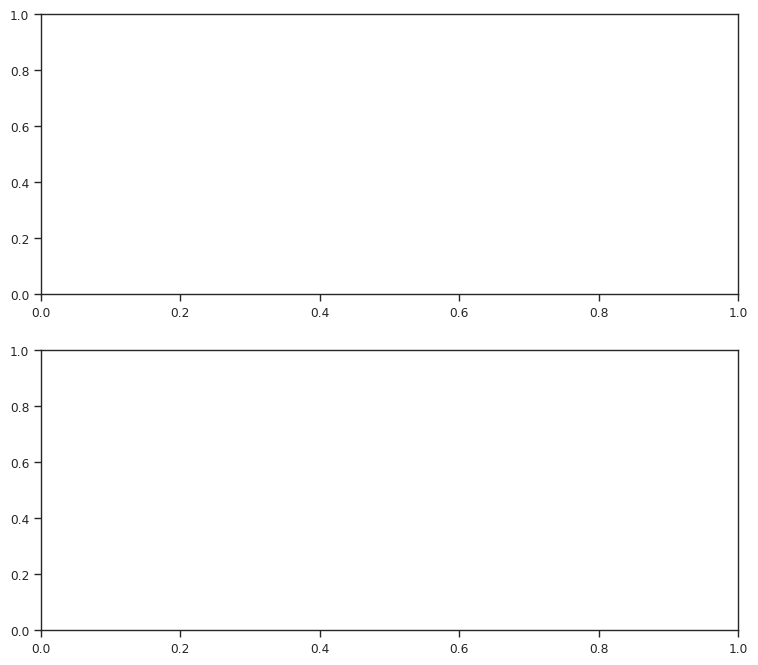

In [656]:
# set up the figure
fig = plt.figure(figsize=(9, 8))

ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)

In [657]:
cols = ['bin0', 'bin1', 'bin2','bin3','bin4','bin5','co', 'o3','no', 'no2']

pal = sns.color_palette()

colors = [pal[3], pal[2], pal[4], pal[5]]
colors += sns.color_palette("Blues", 6)
colors.reverse()

In [658]:
ax1 = sns.barplot(x='variable',y='value',
        data=comp2,
        ax=ax1, hue='species',hue_order=cols,
        palette=colors, saturation=1, edgecolor='black', linewidth=0.25,
        errwidth=.75)

/tmp/ipykernel_57635/2976516543.py:1: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0.75}` instead.

  ax1 = sns.barplot(x='variable',y='value',


In [659]:
ax1.set_ylim(-0.2, 1)
ax1.set_xlabel("")
ax1.set_ylabel("Percent of Species Signal\nDescribed by Factor", fontsize=14)
ax1.set(yticks=np.linspace(-0.2, 1, 13), yticklabels=["","","0","","","","","50","","","","","100"])
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.axhline(y=0, color='black', linestyle='-', lw =0.5)

In [660]:
handles, _ = ax1.get_legend_handles_labels()
labels = ["Bin 0", "Bin 1", "Bin 2", "Bin 3","Bin 4","Bin 5","CO","$O_3$","$NO$", "$NO_2$"]
ax1.legend(handles, labels)

In [661]:
ax2.plot(ts_day.index, ts_day["factor1"], label="Factor 1 ", lw=1, color=sns.xkcd_rgb['slate blue'])
ax2.plot(ts_day.index, ts_day["factor2"], label="Factor 2", lw=1, color=sns.xkcd_rgb['dull green'])
ax2.plot(ts_day.index, ts_day["factor3"], label="Factor 3", lw=1, color=sns.xkcd_rgb['dark lavender'])
ax2.plot(ts_day.index, ts_day["factor4"], label="Factor 4", lw=1, color=sns.xkcd_rgb['faded red'])

ax2.set_ylabel("Factor Intensity (a.u.)", fontsize=14)

#last 6 months
ax2.set_xlim(ts_day.index[-180], ts_day.index[-1])
#ax2.set_xlim(ts_day.index[0], ts_day.index[-1])

ax2.legend(loc='upper right',fontsize=10)
ax2.tick_params(axis='both', which='major', labelsize=14)

In [662]:
ax1.set_title('(a)',fontsize=14)
ax2.set_title('(b)',fontsize=14)

Text(0.5, 1.0, '(b)')

In [663]:
plt.gcf().text(0.09, 0.9, "(a)", fontsize=12)
plt.gcf().text(0.5, 0.9, "(b)", fontsize=12)
plt.gcf().text(0.09,0.9,'MOD-00397',fontsize=12)

plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [664]:
#fig.savefig('/home/pmg2147/ModulAir NMF/OceanRoof/time_barchart_MOD-00068_4_factor.png')

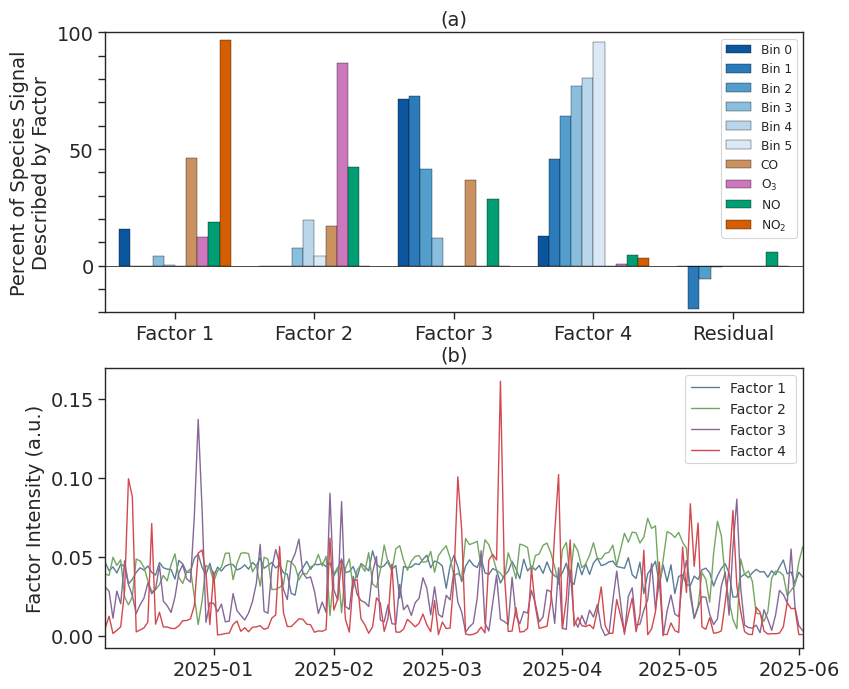

In [665]:
fig

## Setting Up Diurnal Figure

In [666]:
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2,Factor 3,Factor 4
0,2024-05-14 21:00:00,0.065395,0.023049,0.046750,0.071038,0.073593,0.040123,0.706939,0.169309,0.995728,0.209911,0.017150,0.038207,0.134333,0.007507
1,2024-05-14 22:00:00,0.061393,0.020828,0.042189,0.065574,0.069264,0.037037,0.696768,0.124244,0.759528,0.194400,0.016456,0.028775,0.130712,0.004313
2,2024-05-14 23:00:00,0.044959,0.016940,0.035348,0.054645,0.056277,0.030864,0.621397,0.088358,0.508038,0.177881,0.015469,0.020458,0.113285,0.000977
3,2024-05-15 00:00:00,0.032868,0.009164,0.018244,0.027322,0.030303,0.015432,0.403795,0.095452,0.366835,0.225624,0.018256,0.018183,0.066560,0.000000
4,2024-05-15 01:00:00,0.063522,0.025826,0.051311,0.076503,0.073593,0.043210,0.696518,0.024411,0.271164,0.450242,0.035816,0.003190,0.110893,0.008865


In [667]:
#prepping data
ts = ts.set_index('timestamp_local')
ts['Hour'] = ts.index.hour
ts.head()

,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2,Factor 3,Factor 4,Hour
timestamp_local,,,,,,,,,,,,,,,
2024-05-14 21:00:00,0.065395,0.023049,0.046750,0.071038,0.073593,0.040123,0.706939,0.169309,0.995728,0.209911,0.017150,0.038207,0.134333,0.007507,21
2024-05-14 22:00:00,0.061393,0.020828,0.042189,0.065574,0.069264,0.037037,0.696768,0.124244,0.759528,0.194400,0.016456,0.028775,0.130712,0.004313,22
2024-05-14 23:00:00,0.044959,0.016940,0.035348,0.054645,0.056277,0.030864,0.621397,0.088358,0.508038,0.177881,0.015469,0.020458,0.113285,0.000977,23
2024-05-15 00:00:00,0.032868,0.009164,0.018244,0.027322,0.030303,0.015432,0.403795,0.095452,0.366835,0.225624,0.018256,0.018183,0.066560,0.000000,0
2024-05-15 01:00:00,0.063522,0.025826,0.051311,0.076503,0.073593,0.043210,0.696518,0.024411,0.271164,0.450242,0.035816,0.003190,0.110893,0.008865,1


In [668]:
#groupping by hour and calculate the mean
diurnal_data = ts.groupby('Hour')[['Factor 1','Factor 2','Factor 3','Factor 4']].mean()
diurnal_data.index = diurnal_data.index.map(lambda x: "{:02d}:00".format(x))
diurnal_data

,Factor 1,Factor 2,Factor 3,Factor 4
Hour,,,,
00:00,0.039707,0.045074,0.035630,0.016474
01:00,0.039073,0.043758,0.033682,0.016934
02:00,0.038619,0.042533,0.032426,0.018431
03:00,0.037996,0.041466,0.031246,0.019169
04:00,0.037558,0.040278,0.030605,0.019454
05:00,0.037689,0.038836,0.030774,0.019445
06:00,0.037392,0.038038,0.031138,0.019831
07:00,0.036988,0.037837,0.032475,0.019410
08:00,0.035372,0.039148,0.034524,0.017421


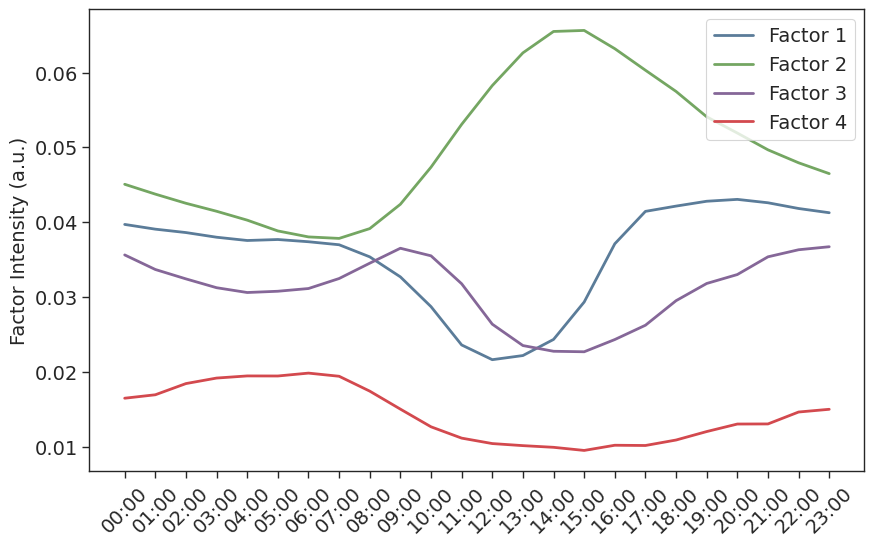

In [669]:
# set up the figure
plt.figure(figsize=(10, 6))

plt.plot(diurnal_data.index, diurnal_data['Factor 1'], label='Factor 1', lw = 2, color=sns.xkcd_rgb['slate blue'])
plt.plot(diurnal_data.index, diurnal_data['Factor 2'], label='Factor 2', lw = 2, color=sns.xkcd_rgb['dull green'])
plt.plot(diurnal_data.index, diurnal_data['Factor 3'], label='Factor 3', lw = 2, color=sns.xkcd_rgb['dark lavender'])
plt.plot(diurnal_data.index, diurnal_data['Factor 4'], label='Factor 4', lw = 2, color=sns.xkcd_rgb['faded red'])

plt.ylabel('Factor Intensity (a.u.)', fontsize = 14)
plt.legend(loc='upper right',fontsize=14)
plt.xticks(range(0, 24))
plt.xticks(rotation=45)

plt.tick_params(labelsize=14)

#plt.savefig('/home/pmg2147/ModulAir NMF/OceanRoof/diurnal_MOD-00068_4_factor.png')
plt.show()